# IMPORTING LIBRARIES


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import joblib
from sklearn.preprocessing import LabelEncoder


# Loading Dataset

In [5]:
df = pd.read_csv("/content/Global_Pollution_Analysis.csv")

In [6]:
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [7]:
df.tail()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
195,Latvia,2004,115.84,78.75,42.34,49503.35,81.23,4.85,17.38,4065.66,6.28,92.96,14818.18
196,Bangladesh,2002,121.82,120.97,63.95,74694.68,25.89,46.22,16.56,36905.26,15.18,114.02,59238.04
197,Korea,2011,149.73,146.92,37.04,2818.85,293.27,38.46,38.36,24700.29,14.11,183.06,28895.94
198,Vanuatu,2002,237.20,113.63,101.96,68746.82,305.61,28.82,32.17,1443.62,12.44,40.65,17068.01
199,Croatia,2010,135.50,158.43,89.80,36182.44,172.24,5.55,45.96,45405.35,11.72,166.62,30304.59


In [9]:
df.shape

(200, 13)

In [10]:
df.columns

Index(['Country', 'Year', 'Air_Pollution_Index', 'Water_Pollution_Index',
       'Soil_Pollution_Index', 'Industrial_Waste (in tons)',
       'Energy_Recovered (in GWh)', 'CO2_Emissions (in MT)',
       'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)',
       'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)',
       'GDP_Per_Capita (in USD)'],
      dtype='object')

In [11]:
df.info

<bound method DataFrame.info of           Country  Year  Air_Pollution_Index  Water_Pollution_Index  \
0         Hungary  2005               272.70                 124.27   
1       Singapore  2001                86.72                  60.34   
2         Romania  2016                91.59                  83.36   
3    Cook Islands  2018               280.61                  67.16   
4        Djibouti  2008               179.16                 127.53   
..            ...   ...                  ...                    ...   
195        Latvia  2004               115.84                  78.75   
196    Bangladesh  2002               121.82                 120.97   
197         Korea  2011               149.73                 146.92   
198       Vanuatu  2002               237.20                 113.63   
199       Croatia  2010               135.50                 158.43   

     Soil_Pollution_Index  Industrial_Waste (in tons)  \
0                   51.95                    94802.83   
1                  117.22                    56283.92   
2                  121.72                    56256.02   
3                   93.58                    74864.73   
4                  121.55                    76862.06   
..                    ...                         ...   
195                 42.34                    49503.35   
196                 63.95                    74694.68   
197                 37.04                     2818.85   
198                101.96                    68746.82   
199                 89.80                    36182.44   

     Energy_Recovered (in GWh)  CO2_Emissions (in MT)  Renewable_Energy (%)  \
0                       158.14                   5.30                 41.11   
1                       498.04                   6.34                 36.44   
2                       489.51                  49.69                  9.38   
3                       145.18                   8.91                 18.97   
4                        40.38                  14.93                 34.00   
..                         ...                    ...                   ...   
195                      81.23                   4.85                 17.38   
196                      25.89                  46.22                 16.56   
197                     293.27                  38.46                 38.36   
198                     305.61                  28.82                 32.17   
199                     172.24                   5.55                 45.96   

     Plastic_Waste_Produced (in tons)  Energy_Consumption_Per_Capita (in MWh)  \
0                            37078.88                                   12.56   
1                            33128.20                                    5.23   
2                            18803.46                                   13.15   
3                             9182.27                                    0.78   
4                            39235.12                                   12.84   
..                                ...                                     ...   
195                           4065.66                                    6.28   
196                          36905.26                                   15.18   
197                          24700.29                                   14.11   
198                           1443.62                                   12.44   
199                          45405.35                                   11.72   

     Population (in millions)  GDP_Per_Capita (in USD)  
0                       42.22                 20972.96  
1                      137.25                 34850.41  
2                      124.47                 57773.15  
3                       67.80                 21837.51  
4                      186.52                 41379.37  
..                        ...                      ...  
195                     92.96                 14818.18  
196                    114.02                 59238.

In [12]:
df.describe()

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
count,200.000000,200.00000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,2009.335000,180.62695,115.068100,76.488550,52891.68150,260.448700,24.878100,27.799700,24492.893550,9.43575,104.271300,35307.602400
std,5.765325,67.07331,47.580911,39.692727,27224.49169,147.141923,14.470892,12.361879,14421.356002,5.57567,56.906574,19481.714455
min,2000.000000,50.30000,31.130000,11.150000,1019.37000,11.730000,1.920000,5.040000,542.950000,0.53000,2.320000,1298.700000
25%,2004.000000,134.97250,74.550000,40.895000,31201.97250,118.355000,11.220000,17.700000,12843.882500,4.58250,60.960000,19525.020000
50%,2010.000000,183.38500,112.305000,78.600000,55299.15000,273.140000,25.355000,29.170000,24121.540000,9.22500,104.965000,35043.325000
75%,2014.000000,237.42500,157.477500,109.212500,74805.82500,384.957500,38.550000,37.072500,36516.232500,13.99750,150.930000,51629.547500
max,2019.000000,297.95000,199.320000,149.230000,99739.36000,499.980000,49.690000,49.560000,49852.280000,19.98000,198.820000,69143.140000


# Check for Missing Values

In [13]:
df.isnull().sum()

,0
Country,0
Year,0
Air_Pollution_Index,0
Water_Pollution_Index,0
Soil_Pollution_Index,0
Industrial_Waste (in tons),0
Energy_Recovered (in GWh),0
CO2_Emissions (in MT),0
Renewable_Energy (%),0
Plastic_Waste_Produced (in tons),0


Duplicate Rows Check!

In [14]:
df.duplicated().sum()

np.int64(0)

# IF HAD DUPLICATES

In [16]:
df.drop_duplicates(inplace=True)
df.fillna(df.mean(numeric_only=True), inplace=True)

# Exploratory DATA Analysis (EDA)

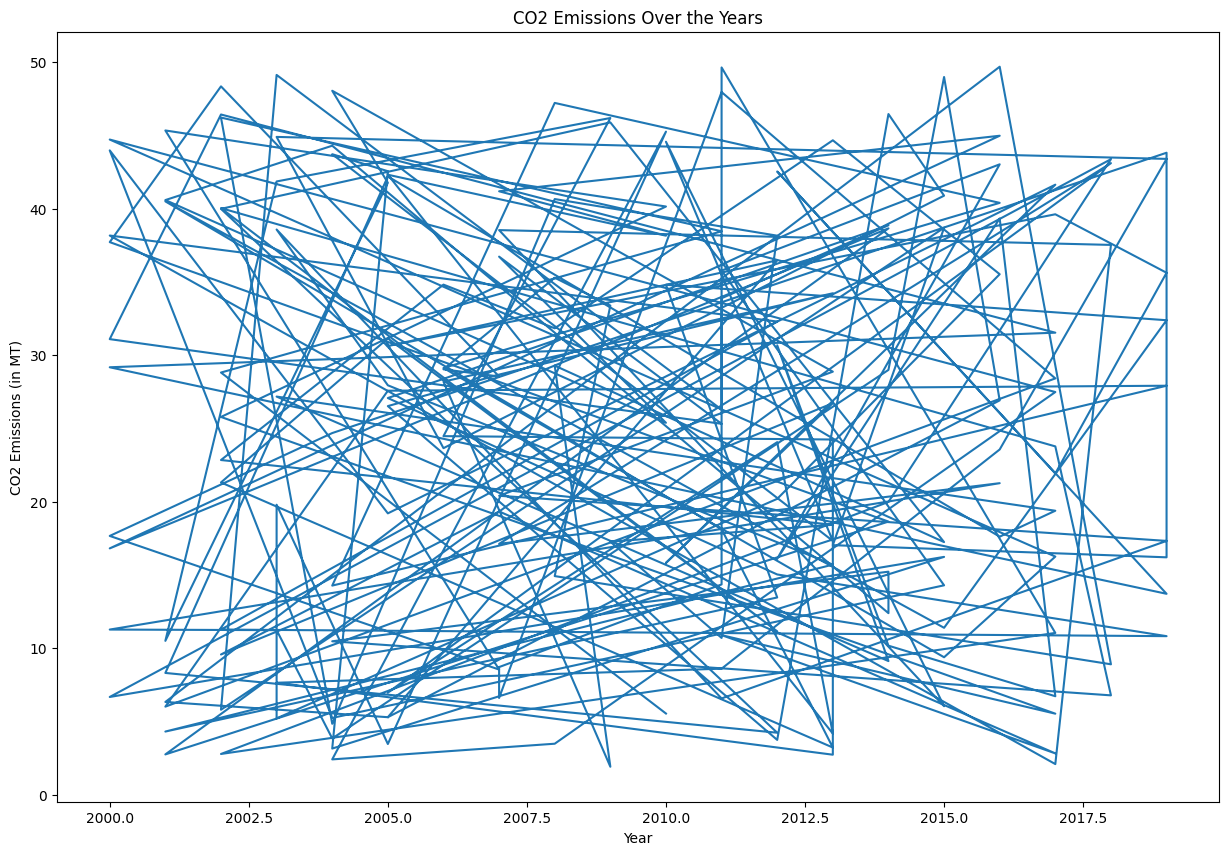

In [19]:
plt.figure(figsize=(15,10))
plt.plot(df["Year"], df["CO2_Emissions (in MT)"])
plt.title("CO2 Emissions Over the Years")
plt.xlabel("Year")
plt.ylabel("CO2 Emissions (in MT)")
plt.show()

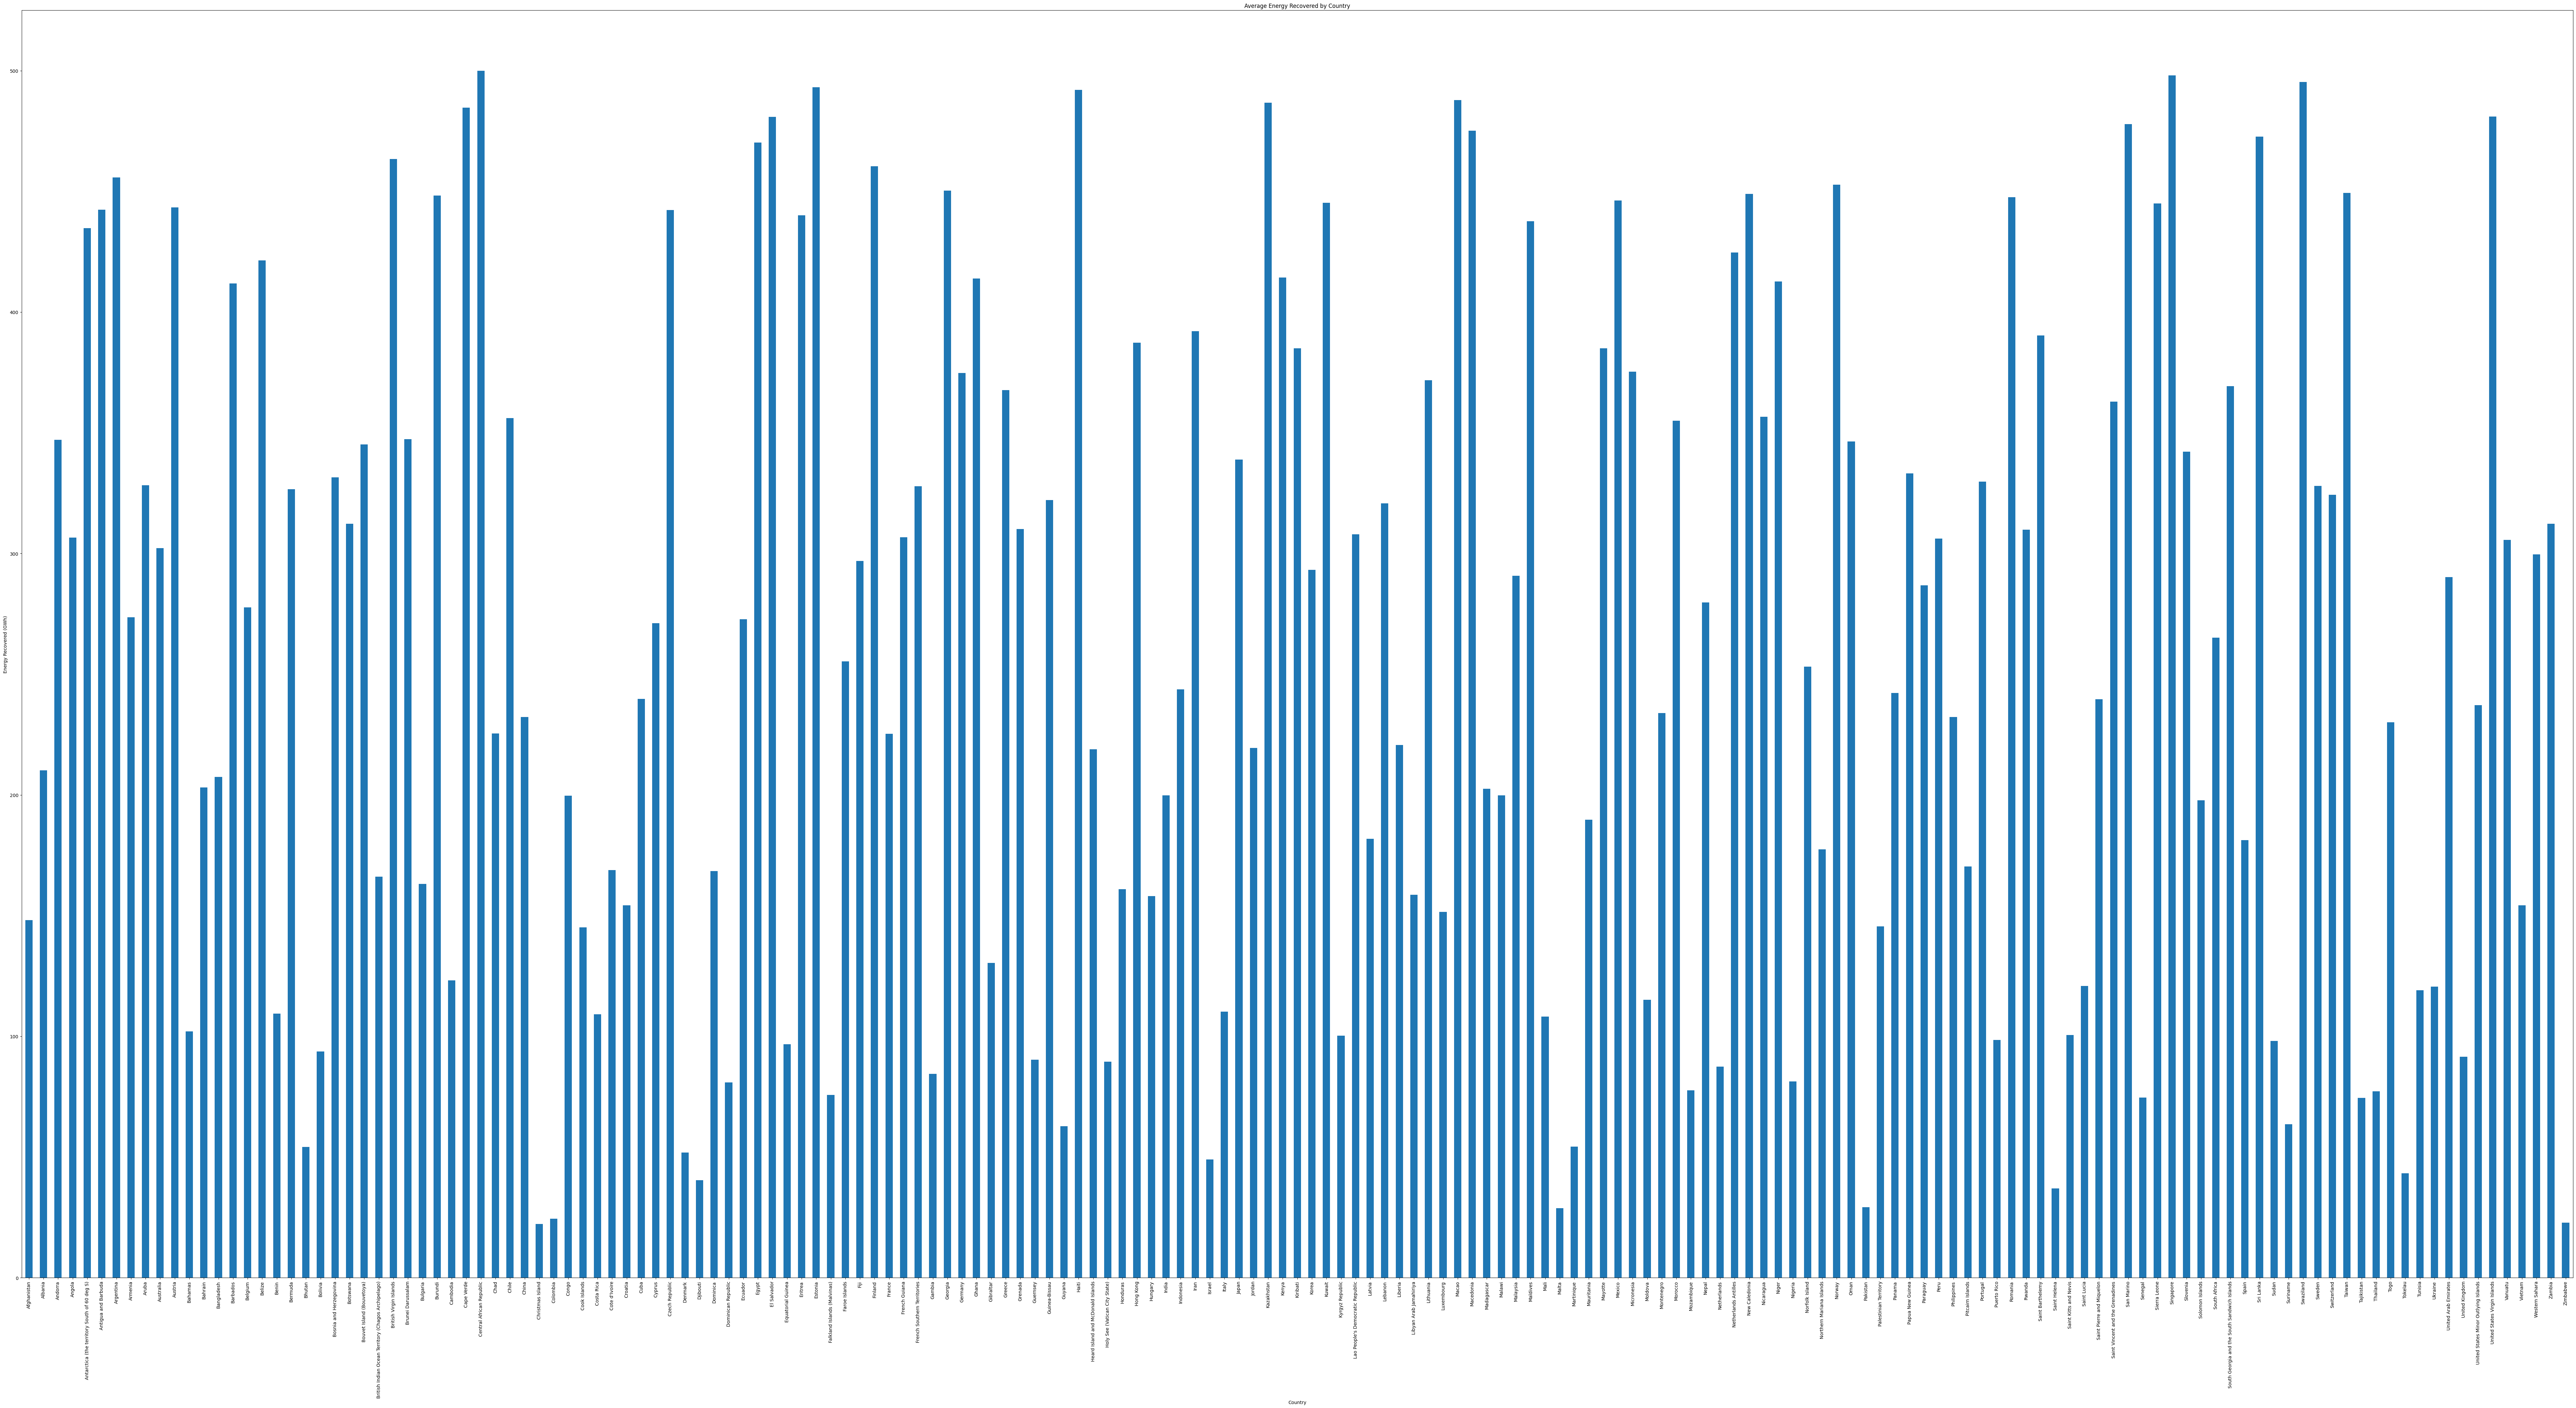

In [21]:
plt.figure(figsize=(100,50))
df.groupby("Country")["Energy_Recovered (in GWh)"].mean().plot(kind="bar")
plt.title("Average Energy Recovered by Country")
plt.xlabel("Country")
plt.ylabel("Energy Recovered (GWh)")
plt.xticks(rotation=90)
plt.show()

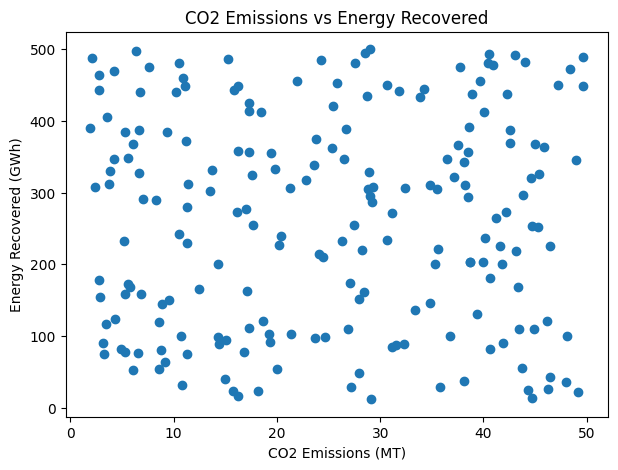

In [22]:
plt.figure(figsize=(7,5))
plt.scatter(df["CO2_Emissions (in MT)"], df["Energy_Recovered (in GWh)"])
plt.title("CO2 Emissions vs Energy Recovered")
plt.xlabel("CO2 Emissions (MT)")
plt.ylabel("Energy Recovered (GWh)")
plt.show()

# Correlation

In [23]:
df.corr(numeric_only=True)

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
Year,1.000000,0.008147,0.007790,0.052949,-0.064372,0.088332,0.002163,0.079472,-0.108469,-0.073536,0.144039,-0.141585
Air_Pollution_Index,0.008147,1.000000,-0.022540,0.036020,0.033252,0.002997,-0.038179,0.011301,-0.018517,-0.053284,-0.028884,-0.069371
Water_Pollution_Index,0.007790,-0.022540,1.000000,-0.020505,0.126092,-0.041828,-0.002979,-0.056183,0.044215,-0.001960,0.239446,-0.019975
Soil_Pollution_Index,0.052949,0.036020,-0.020505,1.000000,0.026609,0.064076,0.041913,-0.077602,0.129932,-0.023043,-0.100273,0.115521
Industrial_Waste (in tons),-0.064372,0.033252,0.126092,0.026609,1.000000,-0.161309,-0.060737,-0.149251,0.066844,0.017323,-0.030398,0.061563
Energy_Recovered (in GWh),0.088332,0.002997,-0.041828,0.064076,-0.161309,1.000000,0.024758,0.043533,-0.072946,-0.030284,-0.075100,0.004535
CO2_Emissions (in MT),0.002163,-0.038179,-0.002979,0.041913,-0.060737,0.024758,1.000000,-0.038888,0.065154,-0.011750,0.020784,0.029267
Renewable_Energy (%),0.079472,0.011301,-0.056183,-0.077602,-0.149251,0.043533,-0.038888,1.000000,-0.125175,0.040398,-0.008378,-0.221096
Plastic_Waste_Produced (in tons),-0.108469,-0.018517,0.044215,0.129932,0.066844,-0.072946,0.065154,-0.125175,1.000000,-0.021884,-0.029782,0.090283
Energy_Consumption_Per_Capita (in MWh),-0.073536,-0.053284,-0.001960,-0.023043,0.017323,-0.030284,-0.011750,0.040398,-0.021884,1.000000,0.040493,0.137791


# Select Features (X) and Target (y)

In [24]:
X = df[[
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "Industrial_Waste (in tons)",
    "CO2_Emissions (in MT)",
    "Renewable_Energy (%)",
    "Energy_Consumption_Per_Capita (in MWh)",
    "Population (in millions)",
    "GDP_Per_Capita (in USD)"
]]
y = df["Energy_Recovered (in GWh)"]

# Train-Test-Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Linear Regression


In [26]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
comparison.head(10)

,Actual,Predicted
95,307.89,245.327043
15,367.65,266.204929
30,109.13,321.220011
158,93.73,267.474682
128,54.32,236.663836
115,481.67,287.362360
69,75.70,231.210376
170,98.54,268.263921
174,385.04,266.877462
45,421.37,203.676956


EVALUATION METRICS

In [27]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

MAE: 144.40314527304866
MSE: 25857.632475242448
RMSE: 160.80308602524534
R2 Score: -0.06928209050417355


R2 score is negetive so needs improvement